# Gamma Ray Bursts

Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 



In [3]:
import numpy as np
import scipy.stats as stats
import pylab as plt 

In [4]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

C:\Users\utente\AppData\Local\Temp\ipykernel_13268\3973052632.py:9: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [5]:
data

array([['GRB260421C*', 'GRB260421B', 'GRB260421A', ..., 'GRB910424A*',
        'GRB910423A*', 'GRB910421A*'],
       ['GRB260421351', 'GRB260421176', 'GRB260421092', ..., 'None',
        'None', 'None'],
       ['8:25:18.055', '4:13:21', '2:12:44', ..., '19:43:25.064',
        '19:51:15.804', '9:14:03.800'],
       ...,
       ['19.2000', '18.1510', '1.5410', ..., '3.1360', '208.5760',
        '5.6960'],
       ['True', 'False', 'True', ..., 'False', 'False', 'False'],
       ['61151.35090341', '61151.17593750', '61151.09217593', ...,
        '48370.82181787', '48369.82726625', '48367.38476620']],
      shape=(15, 9086), dtype='<U14')

In [6]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

In [27]:
idx_t90 = np.where(names == 'T90')[0][0]
t90 = data[idx_t90, :].astype(float)
print(t90)

idx_fluence = np.where(names == 'fluence')[0][0]
fluence= data[idx_fluence, :].astype(float)

print(fluence)

[ 19.2    17.981   1.344 ...   3.136 208.576   5.184]
[6.0902e-06 1.1287e-05 3.3135e-07 ... 2.4858e-08 1.6510e-07 2.6055e-06]


In [29]:
print(len(t90),len(fluence))

9086 9086


Text(0, 0.5, 'Fluence [erg/cm$^2$]')

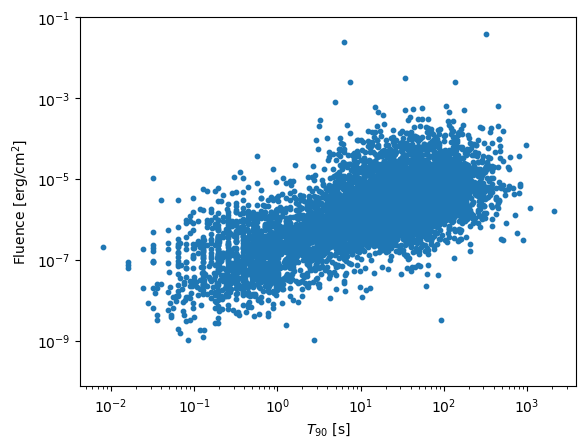

In [38]:
plt.scatter(t90, fluence, s = 10)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$T_{90}$ [s]')
plt.ylabel(r'Fluence [erg/cm$^2$]')

## $K$-Means Clustering

Text(0, 0.5, 'Fluence [erg/cm$^2$]')

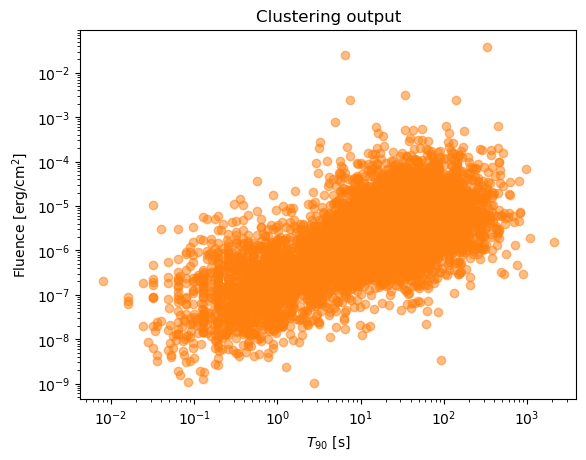

In [44]:

from sklearn.cluster import KMeans
from sklearn import preprocessing

X = np.column_stack((t90, fluence))

clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.5)

# To get some information on these try:
# KMeans?
# help(clf)
plt.title('Clustering output');
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$T_{90}$ [s]')
plt.ylabel(r'Fluence [erg/cm$^2$]')